# Лабораторная работа №1. Вариант 1: Усредняющий фильтр Гаусса с переменным размером ядра и параметрами гауссианы.

In [1]:
import gc
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

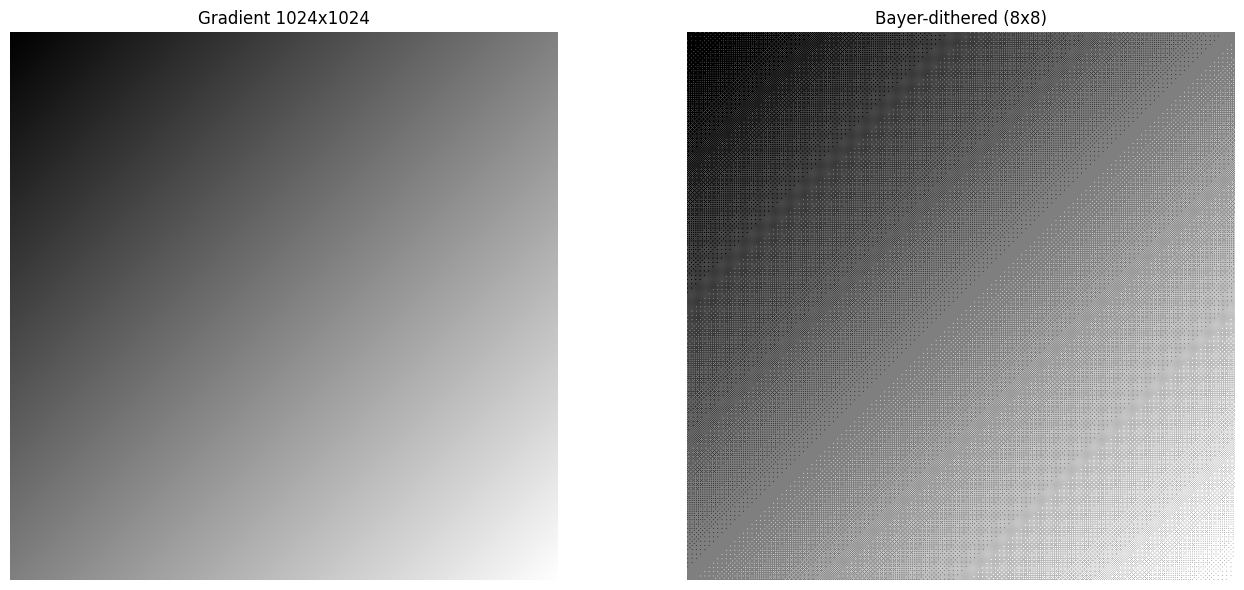

In [2]:
SIZE    = 1024
BAYER_N = 8


def make_gradient(size=SIZE, direction="horizontal"):
    t = np.linspace(0.0, 255.0, size)
    if direction == "horizontal":
        img = np.tile(t, (size, 1))
    elif direction == "vertical":
        img = np.tile(t.reshape(-1, 1), (1, size))
    elif direction == "diagonal":
        img = np.add.outer(t, t) / 2.0
    else:
        raise ValueError("direction must be 'horizontal', 'vertical' or 'diagonal'")
    return np.round(img).astype(np.uint8)


def bayer_matrix(n):
    if n < 1 or (n & (n - 1)) != 0:
        raise ValueError("bayer order must be a power of two")
    m = np.zeros((1, 1), dtype=np.int32)
    while m.shape[0] < n:
        m = np.block([[4 * m, 4 * m + 2],
                      [4 * m + 3, 4 * m + 1]])
    return m


def bayer_dither(gray, n=BAYER_N):
    thr = (bayer_matrix(n) + 0.5) / (n * n)
    h, w = gray.shape
    thr = np.tile(thr, (-(-h // n), -(-w // n)))[:h, :w]
    return np.where(gray / 255.0 > thr, 255, 0).astype(np.uint8)


gradient = make_gradient(SIZE, "diagonal")
dithered = bayer_dither(gradient, BAYER_N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, img, title in zip(
        axes,
        [gradient, dithered],
        [f"Gradient {SIZE}x{SIZE}", f"Bayer-dithered ({BAYER_N}x{BAYER_N})"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
def default_sigma(ksize):
    return 0.3 * ((ksize - 1) * 0.5 - 1) + 0.8


def gaussian_kernel_1d(ksize, sigma=None):
    if ksize < 1 or ksize % 2 == 0:
        raise ValueError("ksize must be a positive odd integer")
    if sigma is None:
        sigma = default_sigma(ksize)
    if sigma <= 0:
        raise ValueError("sigma must be positive")
    x = np.arange(ksize, dtype=np.float64) - (ksize - 1) / 2.0
    k = np.exp(-(x * x) / (2.0 * sigma * sigma))
    return k / k.sum()


def gaussian_kernel_2d(ksize, sigma=None):
    k1 = gaussian_kernel_1d(ksize, sigma)
    return np.outer(k1, k1)

In [4]:
_PAD_TO_CV = {"reflect":   cv2.BORDER_REFLECT_101,
              "symmetric": cv2.BORDER_REFLECT,
              "edge":      cv2.BORDER_REPLICATE,
              "constant":  cv2.BORDER_CONSTANT}


def gaussian_blur_opencv(img, ksize, sigma=None, pad_mode="reflect"):
    if sigma is None:
        sigma = default_sigma(ksize)
    return cv2.GaussianBlur(img, (ksize, ksize), sigma,
                            borderType=_PAD_TO_CV[pad_mode])


def _convolve_axis(img, kernel, axis, pad_mode):
    k, r = kernel.size, kernel.size // 2
    if r >= img.shape[axis]:
        raise ValueError("kernel is larger than the image dimension")
    pad = [(0, 0), (0, 0)]
    pad[axis] = (r, r)
    p = np.pad(img, pad, mode=pad_mode)
    h, w = img.shape
    out = np.zeros((h, w), dtype=np.float64)
    if axis == 0:
        for i in range(k):
            out += kernel[i] * p[i:i + h, :]
    else:
        for i in range(k):
            out += kernel[i] * p[:, i:i + w]
    return out


def gaussian_blur_numpy(img, ksize, sigma=None, pad_mode="reflect"):
    k1 = gaussian_kernel_1d(ksize, sigma)

    def blur_channel(ch):
        ch = np.asarray(ch, dtype=np.float64)
        ch = _convolve_axis(ch, k1, axis=1, pad_mode=pad_mode)
        return _convolve_axis(ch, k1, axis=0, pad_mode=pad_mode)

    if img.ndim == 2:
        out = blur_channel(img)
    elif img.ndim == 3:
        out = np.stack([blur_channel(img[..., c]) for c in range(img.shape[2])], axis=-1)
    else:
        raise ValueError("img must be 2-D (gray) or 3-D (color)")

    if np.issubdtype(img.dtype, np.integer):
        return np.clip(np.rint(out), 0, 255).astype(np.uint8)
    return out

In [5]:
K, S = 21, 5.0

img_f = dithered.astype(np.float64)
cv_f  = gaussian_blur_opencv(img_f, K, S)
np_f  = gaussian_blur_numpy(img_f, K, S)
print(f"float64 : max|cv - np| = {np.abs(cv_f - np_f).max():.3e}")

cv_u = gaussian_blur_opencv(dithered, K, S)
np_u = gaussian_blur_numpy(dithered, K, S)
d = np.abs(cv_u.astype(np.int16) - np_u.astype(np.int16))
print(f"uint8   : max = {d.max()}, mean = {d.mean():.5f}, "
      f"{(d > 0).sum()} of {d.size} pixels differ")

float64 : max|cv - np| = 1.705e-13
uint8   : max = 2, mean = 0.24260, 254375 of 1048576 pixels differ


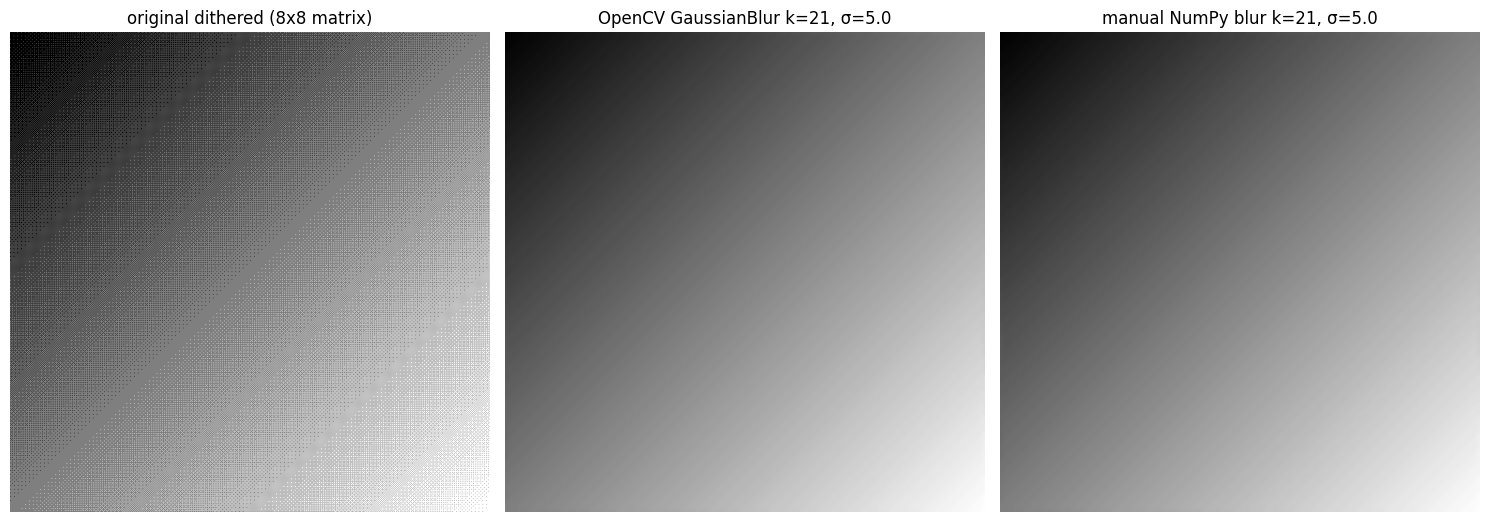

In [6]:
K, S = 21, 5.0
res_cv = gaussian_blur_opencv(dithered, K, S)
res_np = gaussian_blur_numpy(dithered, K, S)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
for ax, img, title in zip(
        axes,
        [dithered, res_cv, res_np],
        [f"original dithered ({BAYER_N}x{BAYER_N} matrix)",
         f"OpenCV GaussianBlur k={K}, σ={S}",
         f"manual NumPy blur k={K}, σ={S}"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
def bench(fn, *args, repeats=5, warmup=1, **kwargs):
    for _ in range(warmup):
        fn(*args, **kwargs)
    gc.collect(); gc.disable()
    try:
        times = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            fn(*args, **kwargs)
            times.append(time.perf_counter() - t0)
    finally:
        gc.enable()
    return float(np.median(times))

k= 3  σ= 0.80 | OpenCV     1.04 ms | NumPy     35.74 ms
k= 5  σ= 1.10 | OpenCV     0.95 ms | NumPy     42.64 ms
k= 7  σ= 1.40 | OpenCV     2.21 ms | NumPy     72.32 ms
k= 9  σ= 1.70 | OpenCV     1.91 ms | NumPy     66.31 ms
k=11  σ= 2.00 | OpenCV     2.35 ms | NumPy     72.96 ms
k=15  σ= 2.60 | OpenCV     3.32 ms | NumPy    102.45 ms
k=21  σ= 3.50 | OpenCV     5.46 ms | NumPy    135.94 ms
k=31  σ= 5.00 | OpenCV     8.85 ms | NumPy    185.07 ms
k=41  σ= 6.50 | OpenCV    13.80 ms | NumPy    223.35 ms
k=51  σ= 8.00 | OpenCV    19.68 ms | NumPy    281.47 ms


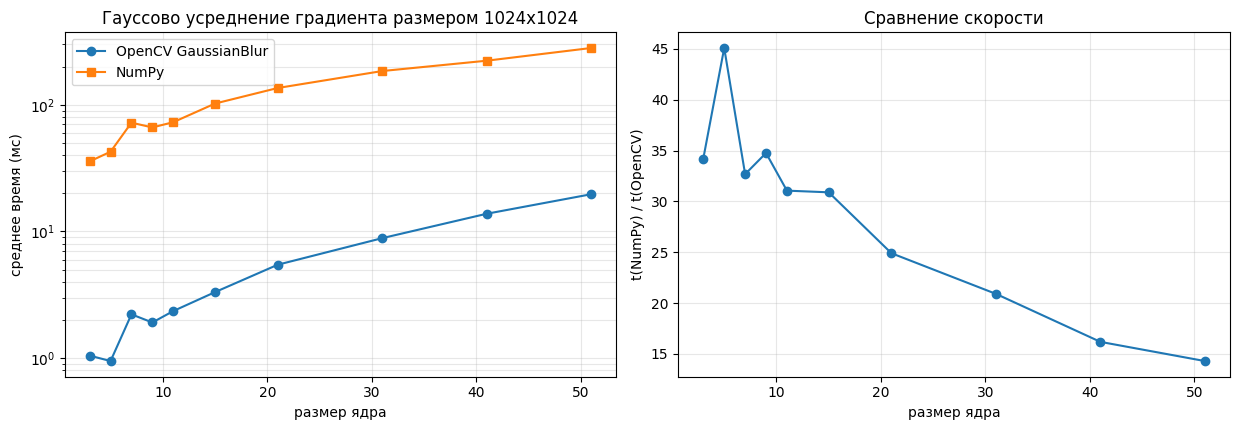

,ksize,sigma (auto),OpenCV [ms],NumPy [ms],NumPy / OpenCV
0,3,0.8,1.04,35.74,34.22
1,5,1.1,0.95,42.64,45.09
2,7,1.4,2.21,72.32,32.68
3,9,1.7,1.91,66.31,34.76
4,11,2.0,2.35,72.96,31.06
5,15,2.6,3.32,102.45,30.90
6,21,3.5,5.46,135.94,24.91
7,31,5.0,8.85,185.07,20.91
8,41,6.5,13.80,223.35,16.19
9,51,8.0,19.68,281.47,14.30


In [9]:
KERNEL_SIZES = [3, 5, 7, 9, 11, 15, 21, 31, 41, 51]

rows = []
for k in KERNEL_SIZES:
    s    = default_sigma(k)
    t_cv = bench(gaussian_blur_opencv,   dithered, k, s)
    t_np = bench(gaussian_blur_numpy,    dithered, k, s)
    rows.append({"ksize": k, "sigma (auto)": round(s, 2),
                 "OpenCV [ms]": 1e3 * t_cv,
                 "NumPy [ms]": 1e3 * t_np,
                 "NumPy / OpenCV": t_np / t_cv})
    print(f"k={k:2d}  σ={s:5.2f} | OpenCV {1e3*t_cv:8.2f} ms | "
          f"NumPy {1e3*t_np:9.2f} ms")

df_k = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax1.plot(df_k["ksize"], df_k["OpenCV [ms]"], "o-", label="OpenCV GaussianBlur")
ax1.plot(df_k["ksize"], df_k["NumPy [ms]"], "s-", label="NumPy")
ax1.set_xlabel("размер ядра")
ax1.set_ylabel("среднее время (мс)")
ax1.set_yscale("log")
ax1.set_title(f"Гауссово усреднение градиента размером {SIZE}x{SIZE}")
ax1.grid(True, which="both", alpha=0.3); ax1.legend()

ax2.plot(df_k["ksize"], df_k["NumPy / OpenCV"], "o-")
ax2.set_xlabel("размер ядра"); ax2.set_ylabel("t(NumPy) / t(OpenCV)")
ax2.set_title("Сравнение скорости")
ax2.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

df_k.round(2)